# LLM Models Comparison Analysis

This notebook provides a comprehensive analysis and visualization of the LLM benchmark comparison results.

## Metrics Analyzed:
- **BLEU Score**: Measures n-gram precision between generated and reference text
- **ROUGE Scores**: Measures recall-based overlap (rouge1, rouge2, rougeL)
- **Semantic Similarity**: Measures semantic closeness to reference
- **Perplexity**: Measures model uncertainty (lower is better)
- **Token Count**: Response length in tokens

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Create figures directory
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Figures will be saved to: {os.path.abspath(FIGURES_DIR)}")

Figures will be saved to: c:\Users\OmarSalah\source\repos\Benchmarking_LLMs\figures


## 1. Load and Preprocess Data

In [2]:
# Load the CSV file
df = pd.read_csv('models_comparison.csv', index_col=0)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (6, 8)

Columns: ['Question', 'Bot', 'Ref', 'BLEU', 'Rouge', 'Sem', 'Perplexity', 'Tokens']


,Question,Bot,Ref,BLEU,Rouge,Sem,Perplexity,Tokens
mistralai/Mistral-7B-Instruct-v0.1,How do I use the app?,You are a helpful assistant.\nQuestion: How do...,The app is simple. You can search for landmark...,2.936199e-155,"{'rouge1': np.float64(0.13846153846153844), 'r...",0.508864,7.059708,"['You', 'are', 'a', 'helpful', 'assistant.', '..."
google/gemma-1.1-7b-it,How do I use the app?,You are a helpful assistant.\nQuestion: How do...,The app is simple. You can search for landmark...,7.095144e-79,"{'rouge1': np.float64(0.12403100775193798), 'r...",0.483193,11.854321,"['You', 'are', 'a', 'helpful', 'assistant.', '..."
google/gemma-3-4b-it,How do I use the app?,You are a helpful assistant.\nQuestion: How do...,The app is simple. You can search for landmark...,8.680763e-232,"{'rouge1': np.float64(0.11864406779661019), 'r...",0.494057,18.104691,"['You', 'are', 'a', 'helpful', 'assistant.', '..."
tiiuae/falcon-7b-instruct,How do I use the app?,You are a helpful assistant.\nQuestion: How do...,The app is simple. You can search for landmark...,1.047702e-231,"{'rouge1': np.float64(0.19753086419753085), 'r...",0.486929,7.179054,"['You', 'are', 'a', 'helpful', 'assistant.', '..."
Qwen/Qwen2.5-7B-Instruct,How do I use the app?,You are a helpful assistant.\nQuestion: How do...,The app is simple. You can search for landmark...,1.939504e-155,"{'rouge1': np.float64(0.1016949152542373), 'ro...",0.517752,15.795847,"['You', 'are', 'a', 'helpful', 'assistant.', '..."


In [3]:
def safe_parse_rouge(rouge_str):
    """Safely parse ROUGE dictionary string."""
    if pd.isna(rouge_str):
        return {'rouge1': np.nan, 'rouge2': np.nan, 'rougeL': np.nan, 'rougeLsum': np.nan}
    try:
        # Handle numpy float notation in string
        rouge_str = str(rouge_str).replace('np.float64(', '').replace(')', '')
        return ast.literal_eval(rouge_str)
    except:
        return {'rouge1': np.nan, 'rouge2': np.nan, 'rougeL': np.nan, 'rougeLsum': np.nan}

def count_tokens(tokens_str):
    """Count number of tokens from token list string."""
    if pd.isna(tokens_str):
        return np.nan
    try:
        tokens = ast.literal_eval(str(tokens_str))
        return len(tokens)
    except:
        return np.nan

# Parse ROUGE scores into separate columns
rouge_data = df['Rouge'].apply(safe_parse_rouge)
df['Rouge1'] = rouge_data.apply(lambda x: x.get('rouge1', np.nan))
df['Rouge2'] = rouge_data.apply(lambda x: x.get('rouge2', np.nan))
df['RougeL'] = rouge_data.apply(lambda x: x.get('rougeL', np.nan))
df['RougeLsum'] = rouge_data.apply(lambda x: x.get('rougeLsum', np.nan))

# Count tokens
df['TokenCount'] = df['Tokens'].apply(count_tokens)

# Extract model name (short version) from index
df['Model'] = df.index.str.split('/').str[-1]

# Convert numeric columns
df['BLEU'] = pd.to_numeric(df['BLEU'], errors='coerce')
df['Sem'] = pd.to_numeric(df['Sem'], errors='coerce')
df['Perplexity'] = pd.to_numeric(df['Perplexity'], errors='coerce')

print("Data preprocessing complete!")
df[['Model', 'Question', 'BLEU', 'Sem', 'Perplexity', 'Rouge1', 'Rouge2', 'RougeL', 'TokenCount']].head(10)

Data preprocessing complete!


,Model,Question,BLEU,Sem,Perplexity,Rouge1,Rouge2,RougeL,TokenCount
mistralai/Mistral-7B-Instruct-v0.1,Mistral-7B-Instruct-v0.1,How do I use the app?,2.936199e-155,0.508864,7.059708,0.138462,0.062500,0.123077,110
google/gemma-1.1-7b-it,gemma-1.1-7b-it,How do I use the app?,7.095144e-79,0.483193,11.854321,0.124031,0.031496,0.124031,113
google/gemma-3-4b-it,gemma-3-4b-it,How do I use the app?,8.680763e-232,0.494057,18.104691,0.118644,0.017241,0.084746,97
tiiuae/falcon-7b-instruct,falcon-7b-instruct,How do I use the app?,1.047702e-231,0.486929,7.179054,0.197531,0.050633,0.148148,64
Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B-Instruct,How do I use the app?,1.939504e-155,0.517752,15.795847,0.101695,0.034286,0.101695,157
deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,DeepSeek-R1-Distill-Qwen-7B,How do I use the app?,8.035074e-232,0.357272,17.468063,0.088235,0.009901,0.078431,185


## 2. Dataset Overview

In [4]:
# Summary statistics
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"\nTotal entries: {len(df)}")
print(f"Unique models: {df['Model'].nunique()}")
print(f"\nModels compared:")
for i, model in enumerate(df['Model'].unique(), 1):
    print(f"  {i}. {model}")

print(f"\n{'=' * 60}")
print("METRICS STATISTICS")
print("=" * 60)
metrics = ['BLEU', 'Sem', 'Perplexity', 'Rouge1', 'Rouge2', 'RougeL', 'TokenCount']
df[metrics].describe()

DATASET SUMMARY

Total entries: 6
Unique models: 6

Models compared:
  1. Mistral-7B-Instruct-v0.1
  2. gemma-1.1-7b-it
  3. gemma-3-4b-it
  4. falcon-7b-instruct
  5. Qwen2.5-7B-Instruct
  6. DeepSeek-R1-Distill-Qwen-7B

METRICS STATISTICS


,BLEU,Sem,Perplexity,Rouge1,Rouge2,RougeL,TokenCount
count,6.000000e+00,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,1.182524e-79,0.474678,12.910281,0.128100,0.034343,0.110021,121.000000
std,2.896581e-79,0.059002,4.985439,0.038263,0.019780,0.026557,43.363579
min,8.035074e-232,0.357272,7.059708,0.088235,0.009901,0.078431,64.000000
25%,9.129828e-232,0.484127,8.347871,0.105932,0.020805,0.088983,100.250000
50%,9.697520e-156,0.490493,13.825084,0.121338,0.032891,0.112386,111.500000
75%,2.687026e-155,0.505163,17.050009,0.134854,0.046546,0.123792,146.000000
max,7.095144e-79,0.517752,18.104691,0.197531,0.062500,0.148148,185.000000


## 3. Aggregate Metrics by Model

In [5]:
# Aggregate metrics by model
metrics_to_aggregate = ['BLEU', 'Sem', 'Perplexity', 'Rouge1', 'Rouge2', 'RougeL', 'TokenCount']

model_stats = df.groupby('Model')[metrics_to_aggregate].agg(['mean', 'std', 'min', 'max'])
model_stats.columns = ['_'.join(col).strip() for col in model_stats.columns.values]

# Create simplified mean table
model_means = df.groupby('Model')[metrics_to_aggregate].mean()
model_means = model_means.round(4)

print("\nAverage Metrics by Model:")
print("=" * 80)
model_means


Average Metrics by Model:


,BLEU,Sem,Perplexity,Rouge1,Rouge2,RougeL,TokenCount
Model,,,,,,,
DeepSeek-R1-Distill-Qwen-7B,0.0,0.3573,17.4681,0.0882,0.0099,0.0784,185.0
Mistral-7B-Instruct-v0.1,0.0,0.5089,7.0597,0.1385,0.0625,0.1231,110.0
Qwen2.5-7B-Instruct,0.0,0.5178,15.7958,0.1017,0.0343,0.1017,157.0
falcon-7b-instruct,0.0,0.4869,7.1791,0.1975,0.0506,0.1481,64.0
gemma-1.1-7b-it,0.0,0.4832,11.8543,0.1240,0.0315,0.1240,113.0
gemma-3-4b-it,0.0,0.4941,18.1047,0.1186,0.0172,0.0847,97.0


## 4. Visualization: BLEU Scores Comparison

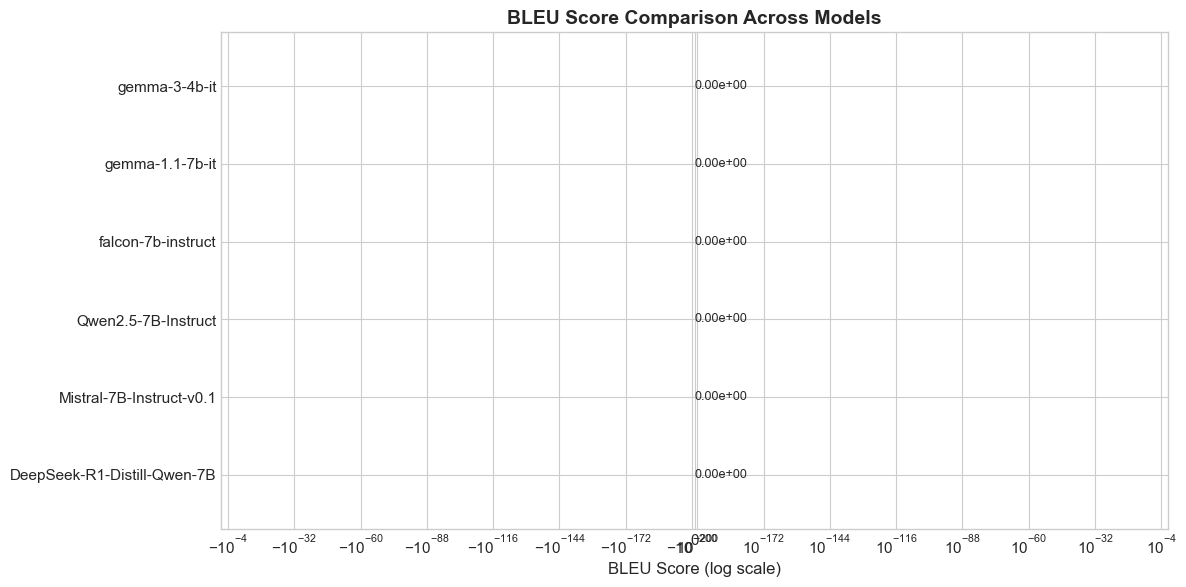

✓ Saved: figures/bleu_comparison.png


In [6]:
# BLEU Score comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('viridis', n_colors=len(model_means))
bleu_sorted = model_means['BLEU'].sort_values(ascending=True)

bars = ax.barh(range(len(bleu_sorted)), bleu_sorted.values, color=colors)
ax.set_yticks(range(len(bleu_sorted)))
ax.set_yticklabels(bleu_sorted.index)
ax.set_xlabel('BLEU Score (log scale)')
ax.set_title('BLEU Score Comparison Across Models', fontweight='bold', fontsize=14)
ax.set_xscale('symlog', linthresh=1e-200)  # Handle very small values

# Add value labels
for i, (idx, val) in enumerate(bleu_sorted.items()):
    ax.text(val * 1.1, i, f'{val:.2e}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/bleu_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/bleu_comparison.png")

## 5. Visualization: Semantic Similarity Comparison

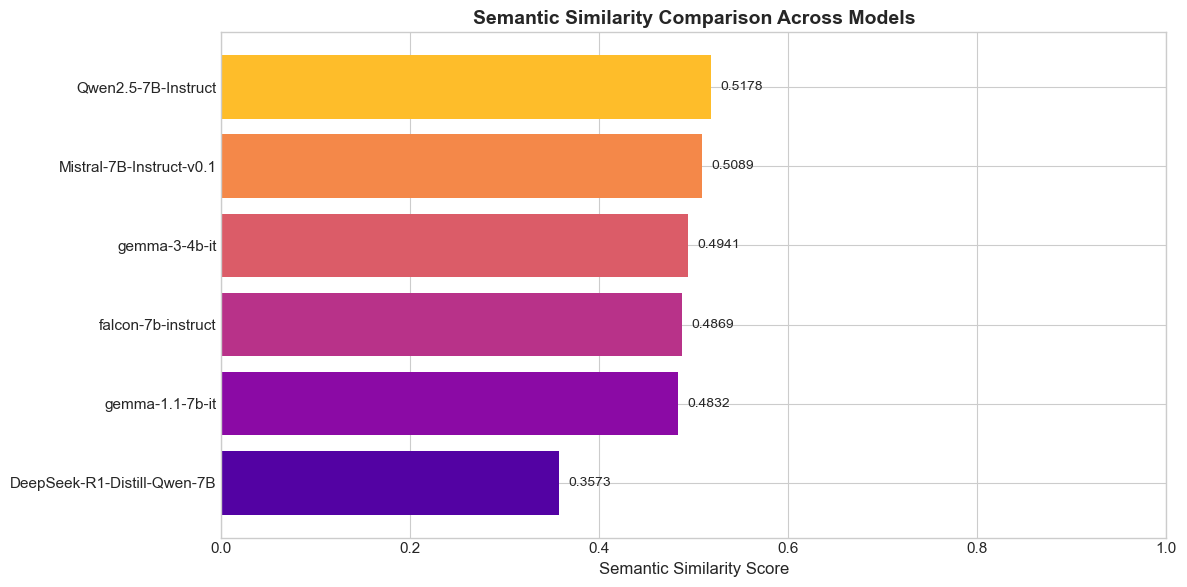

✓ Saved: figures/semantic_similarity_comparison.png


In [7]:
# Semantic Similarity comparison
fig, ax = plt.subplots(figsize=(12, 6))

sem_sorted = model_means['Sem'].sort_values(ascending=True)
colors = sns.color_palette('plasma', n_colors=len(sem_sorted))

bars = ax.barh(range(len(sem_sorted)), sem_sorted.values, color=colors)
ax.set_yticks(range(len(sem_sorted)))
ax.set_yticklabels(sem_sorted.index)
ax.set_xlabel('Semantic Similarity Score')
ax.set_title('Semantic Similarity Comparison Across Models', fontweight='bold', fontsize=14)
ax.set_xlim(0, 1)

# Add value labels
for i, (idx, val) in enumerate(sem_sorted.items()):
    ax.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/semantic_similarity_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/semantic_similarity_comparison.png")

## 6. Visualization: Perplexity Comparison

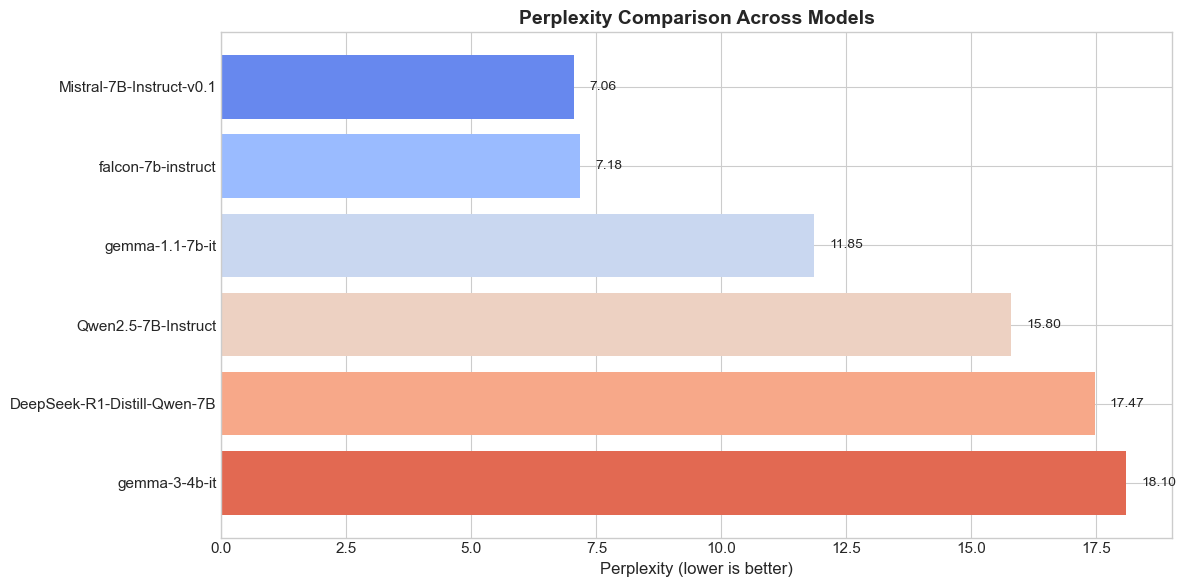

✓ Saved: figures/perplexity_comparison.png


In [8]:
# Perplexity comparison (lower is better)
fig, ax = plt.subplots(figsize=(12, 6))

perp_sorted = model_means['Perplexity'].sort_values(ascending=False)  # Ascending for display (best at top)
colors = sns.color_palette('coolwarm_r', n_colors=len(perp_sorted))

bars = ax.barh(range(len(perp_sorted)), perp_sorted.values, color=colors)
ax.set_yticks(range(len(perp_sorted)))
ax.set_yticklabels(perp_sorted.index)
ax.set_xlabel('Perplexity (lower is better)')
ax.set_title('Perplexity Comparison Across Models', fontweight='bold', fontsize=14)

# Add value labels
for i, (idx, val) in enumerate(perp_sorted.items()):
    ax.text(val + 0.3, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/perplexity_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/perplexity_comparison.png")

## 7. Visualization: ROUGE Scores Comparison

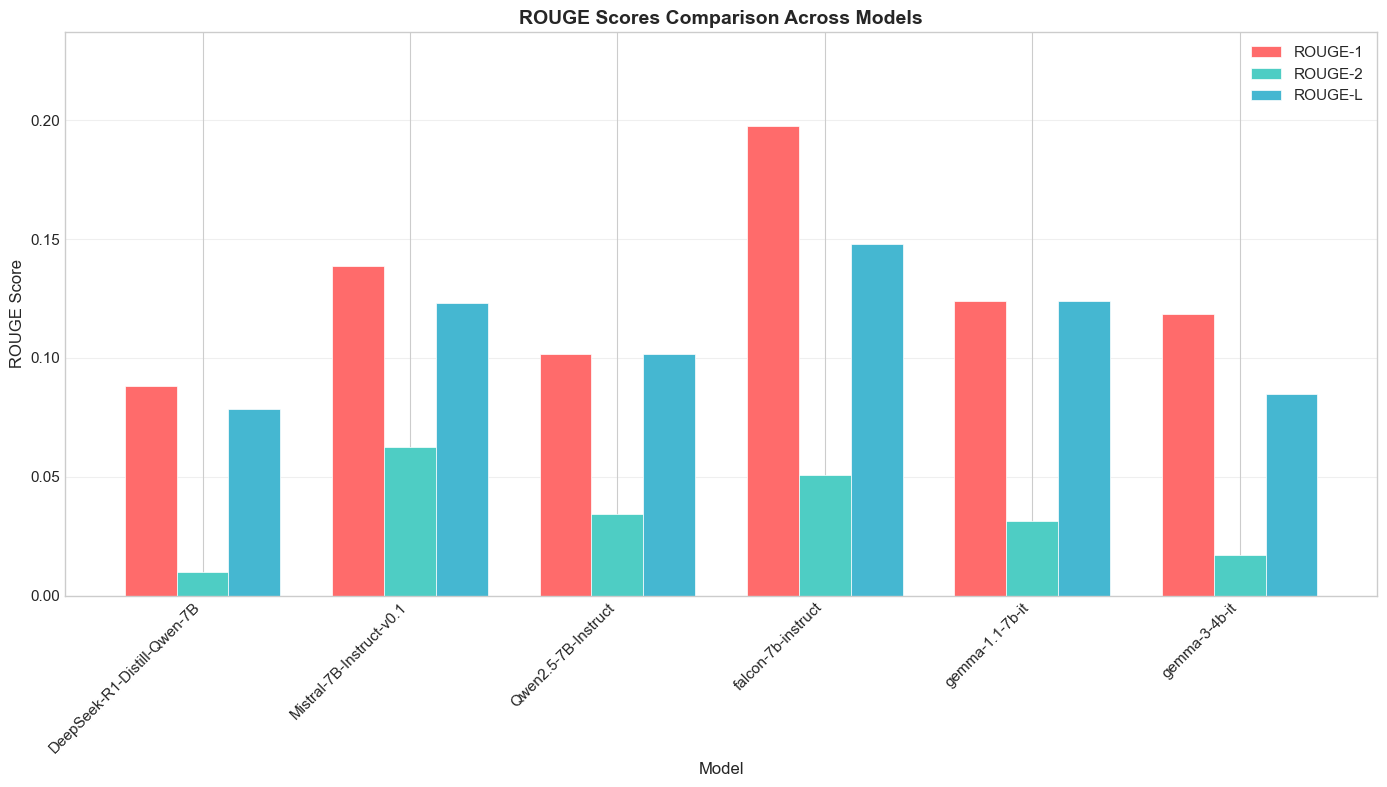

✓ Saved: figures/rouge_comparison.png


In [9]:
# ROUGE Scores comparison (grouped bar chart)
fig, ax = plt.subplots(figsize=(14, 8))

rouge_cols = ['Rouge1', 'Rouge2', 'RougeL']
rouge_data = model_means[rouge_cols]

x = np.arange(len(rouge_data.index))
width = 0.25

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

for i, (col, color, label) in enumerate(zip(rouge_cols, colors, labels)):
    bars = ax.bar(x + i * width, rouge_data[col], width, label=label, color=color, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Model')
ax.set_ylabel('ROUGE Score')
ax.set_title('ROUGE Scores Comparison Across Models', fontweight='bold', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(rouge_data.index, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, max(rouge_data.max()) * 1.2)

# Add grid
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rouge_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/rouge_comparison.png")

## 8. Visualization: Token Count Comparison

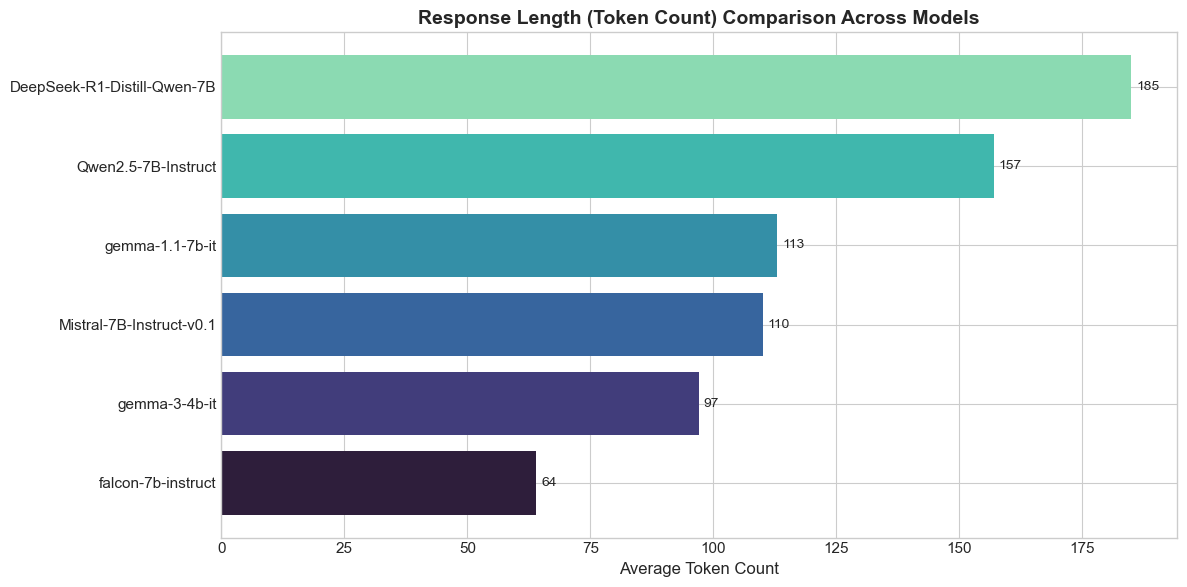

✓ Saved: figures/token_count_comparison.png


In [10]:
# Token Count comparison
fig, ax = plt.subplots(figsize=(12, 6))

token_sorted = model_means['TokenCount'].sort_values(ascending=True)
colors = sns.color_palette('mako', n_colors=len(token_sorted))

bars = ax.barh(range(len(token_sorted)), token_sorted.values, color=colors)
ax.set_yticks(range(len(token_sorted)))
ax.set_yticklabels(token_sorted.index)
ax.set_xlabel('Average Token Count')
ax.set_title('Response Length (Token Count) Comparison Across Models', fontweight='bold', fontsize=14)

# Add value labels
for i, (idx, val) in enumerate(token_sorted.items()):
    ax.text(val + 1, i, f'{val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/token_count_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/token_count_comparison.png")

## 9. Visualization: Comprehensive Metrics Radar Chart

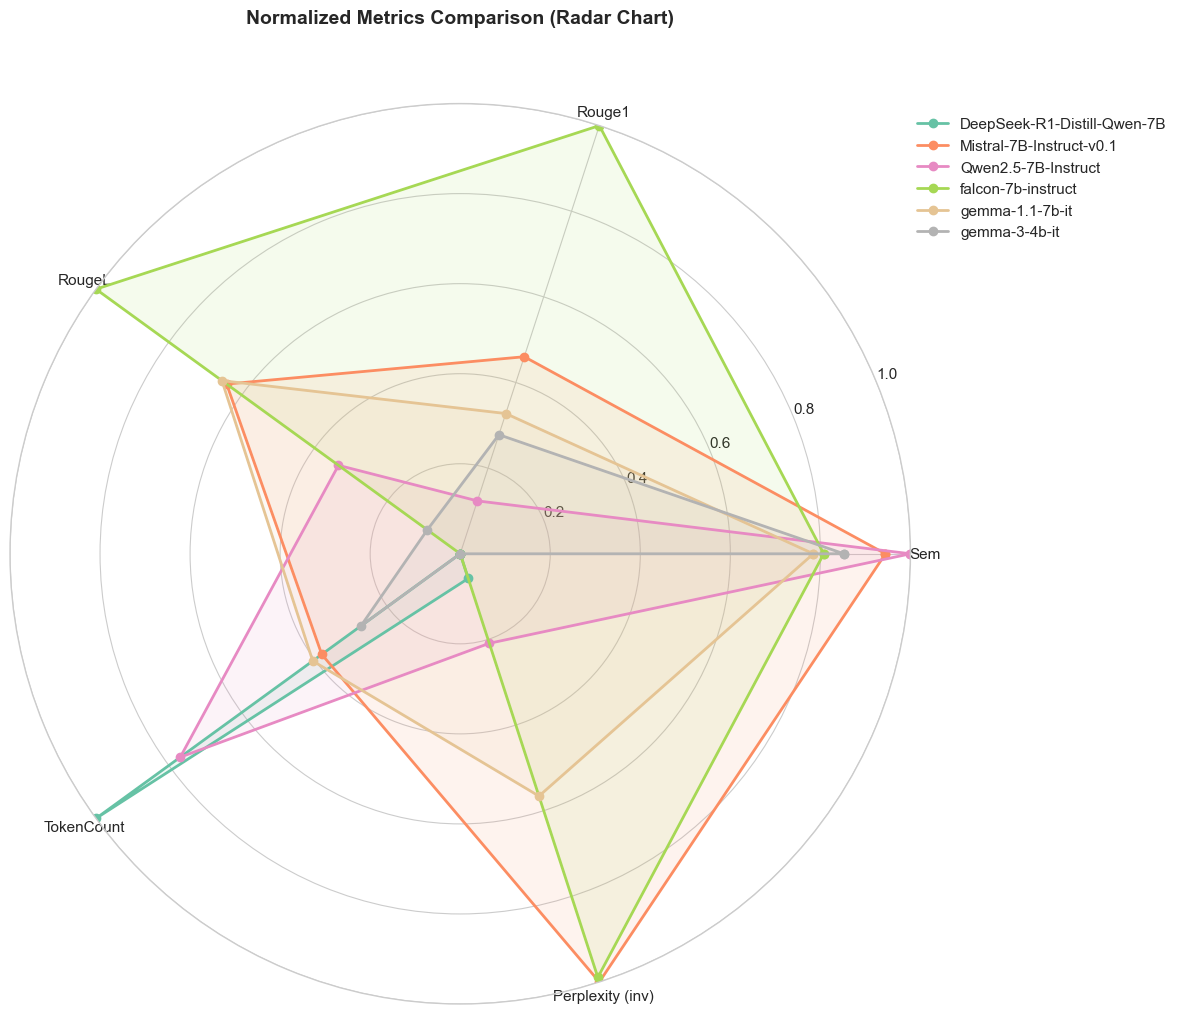

✓ Saved: figures/radar_comparison.png


In [11]:
# Radar Chart for normalized metrics
from math import pi

# Normalize metrics for radar chart (0-1 scale)
metrics_for_radar = ['Sem', 'Rouge1', 'RougeL', 'TokenCount']
radar_data = model_means[metrics_for_radar].copy()

# Normalize each metric
for col in radar_data.columns:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min() + 1e-10)

# Add inverted perplexity (lower perplexity = better, so we invert)
perp_norm = 1 - (model_means['Perplexity'] - model_means['Perplexity'].min()) / (model_means['Perplexity'].max() - model_means['Perplexity'].min() + 1e-10)
radar_data['Perplexity (inv)'] = perp_norm

# Create radar chart
categories = radar_data.columns.tolist()
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

colors = plt.cm.Set2(np.linspace(0, 1, len(radar_data.index)))

for i, (model, row) in enumerate(radar_data.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
plt.title('Normalized Metrics Comparison (Radar Chart)', fontweight='bold', fontsize=14, y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/radar_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/radar_comparison.png")

## 10. Visualization: Correlation Heatmap

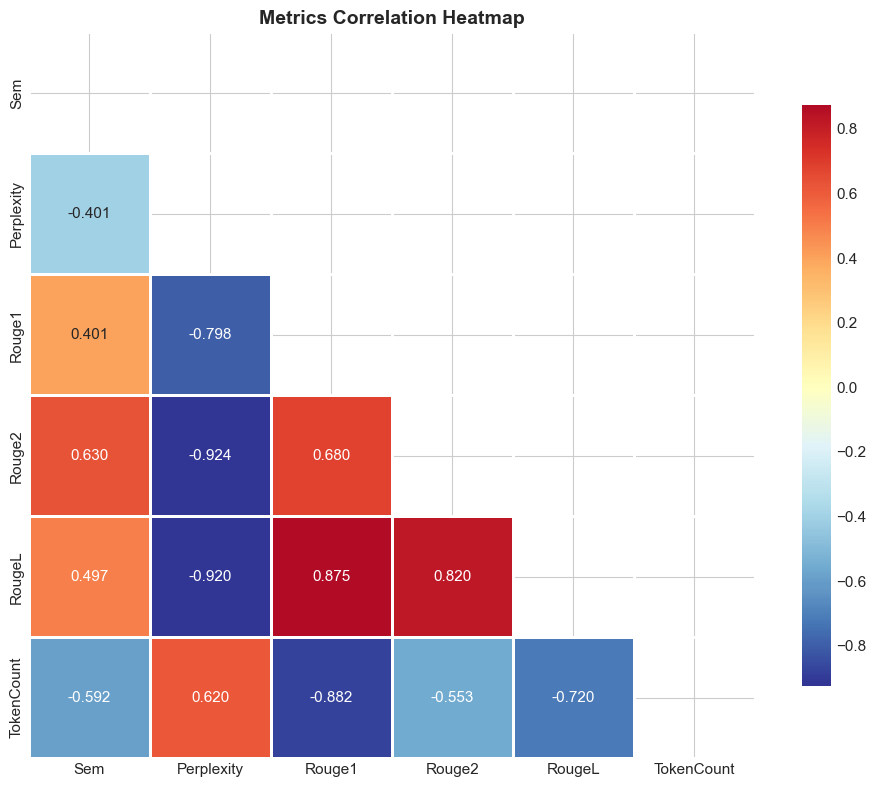

✓ Saved: figures/correlation_heatmap.png


In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['Sem', 'Perplexity', 'Rouge1', 'Rouge2', 'RougeL', 'TokenCount']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=1, fmt='.3f', ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Metrics Correlation Heatmap', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/correlation_heatmap.png")

## 11. Visualization: Box Plots for Distribution Analysis

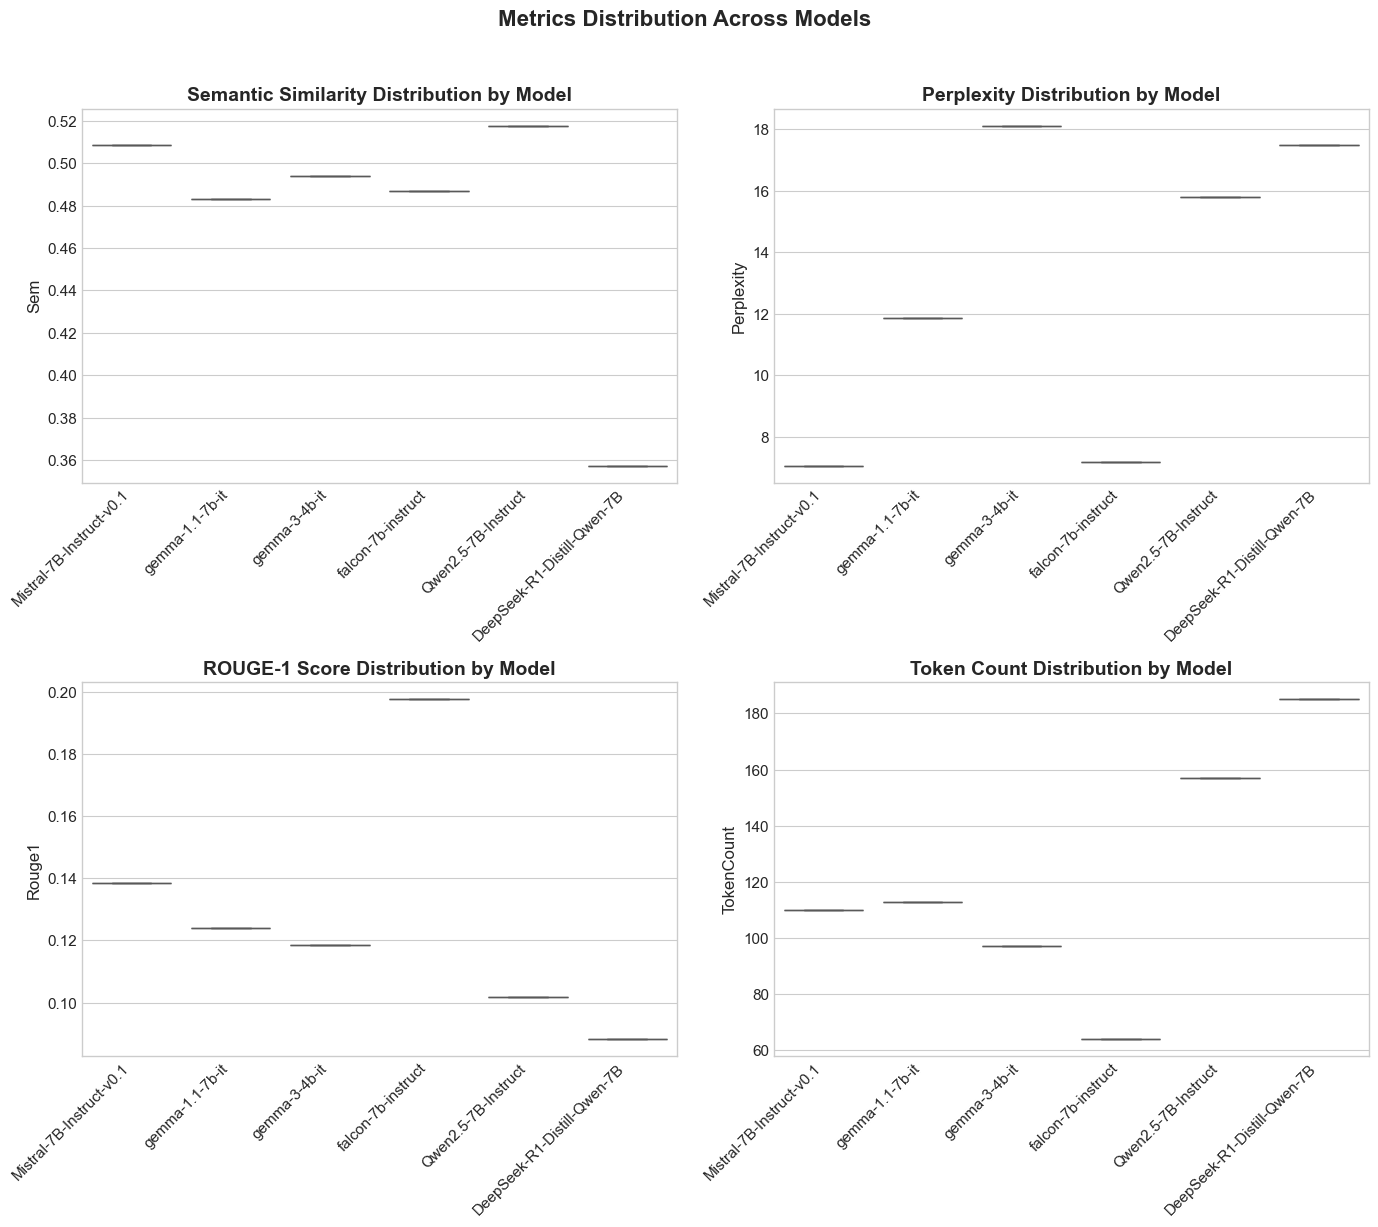

✓ Saved: figures/boxplots_distribution.png


In [13]:
# Box plots for key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

metrics_box = [('Sem', 'Semantic Similarity'), 
               ('Perplexity', 'Perplexity'),
               ('Rouge1', 'ROUGE-1 Score'),
               ('TokenCount', 'Token Count')]

for ax, (metric, title) in zip(axes.flat, metrics_box):
    sns.boxplot(data=df, x='Model', y=metric, ax=ax, palette='Set2')
    ax.set_title(f'{title} Distribution by Model', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('')

plt.suptitle('Metrics Distribution Across Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/boxplots_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/boxplots_distribution.png")

## 12. Visualization: Semantic Similarity vs Perplexity Scatter

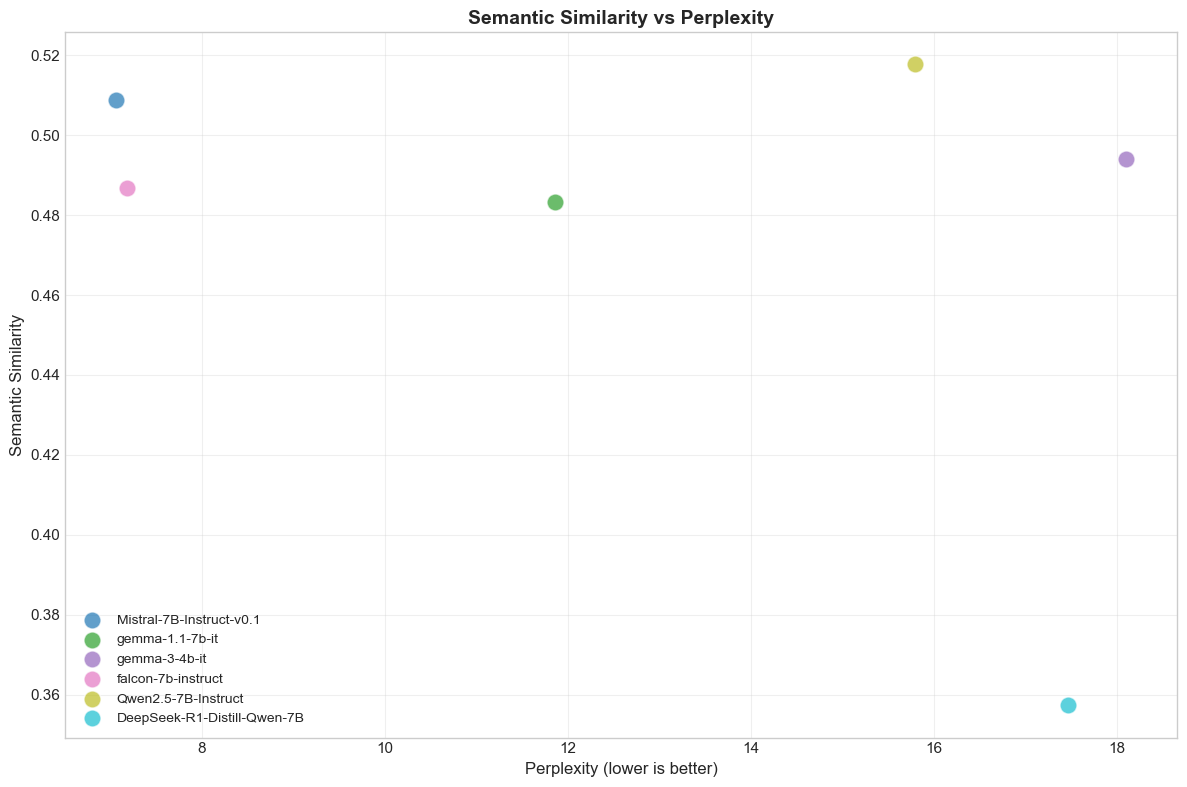

✓ Saved: figures/sem_vs_perplexity_scatter.png


In [14]:
# Scatter plot: Semantic Similarity vs Perplexity
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, df['Model'].nunique()))
model_colors = dict(zip(df['Model'].unique(), colors))

for model in df['Model'].unique():
    mask = df['Model'] == model
    ax.scatter(df.loc[mask, 'Perplexity'], df.loc[mask, 'Sem'], 
               label=model, s=150, alpha=0.7, c=[model_colors[model]],
               edgecolors='white', linewidth=1)

ax.set_xlabel('Perplexity (lower is better)', fontsize=12)
ax.set_ylabel('Semantic Similarity', fontsize=12)
ax.set_title('Semantic Similarity vs Perplexity', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sem_vs_perplexity_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/sem_vs_perplexity_scatter.png")

## 13. Model Ranking Summary

In [15]:
# Create ranking summary
def rank_models(series, ascending=False):
    """Rank models, lower rank is better."""
    return series.rank(ascending=ascending)

rankings = pd.DataFrame(index=model_means.index)
rankings['Semantic Sim Rank'] = rank_models(model_means['Sem'], ascending=False)  # Higher is better
rankings['Perplexity Rank'] = rank_models(model_means['Perplexity'], ascending=True)  # Lower is better
rankings['ROUGE-1 Rank'] = rank_models(model_means['Rouge1'], ascending=False)  # Higher is better
rankings['ROUGE-L Rank'] = rank_models(model_means['RougeL'], ascending=False)  # Higher is better

# Calculate overall rank (average of all ranks)
rankings['Average Rank'] = rankings.mean(axis=1)
rankings['Overall Position'] = rankings['Average Rank'].rank()

rankings_sorted = rankings.sort_values('Average Rank')

print("\n" + "=" * 80)
print("MODEL RANKINGS (lower rank = better performance)")
print("=" * 80)
print(rankings_sorted.to_string())
print("\n" + "=" * 80)
print(f"🏆 Best Overall Model: {rankings_sorted.index[0]}")
print("=" * 80)


MODEL RANKINGS (lower rank = better performance)
                             Semantic Sim Rank  Perplexity Rank  ROUGE-1 Rank  ROUGE-L Rank  Average Rank  Overall Position
Model                                                                                                                      
Mistral-7B-Instruct-v0.1                   2.0              1.0           2.0           3.0          2.00               1.5
falcon-7b-instruct                         4.0              2.0           1.0           1.0          2.00               1.5
gemma-1.1-7b-it                            5.0              3.0           3.0           2.0          3.25               3.0
Qwen2.5-7B-Instruct                        1.0              4.0           5.0           4.0          3.50               4.0
gemma-3-4b-it                              3.0              6.0           4.0           5.0          4.50               5.0
DeepSeek-R1-Distill-Qwen-7B                6.0              5.0           6.0     

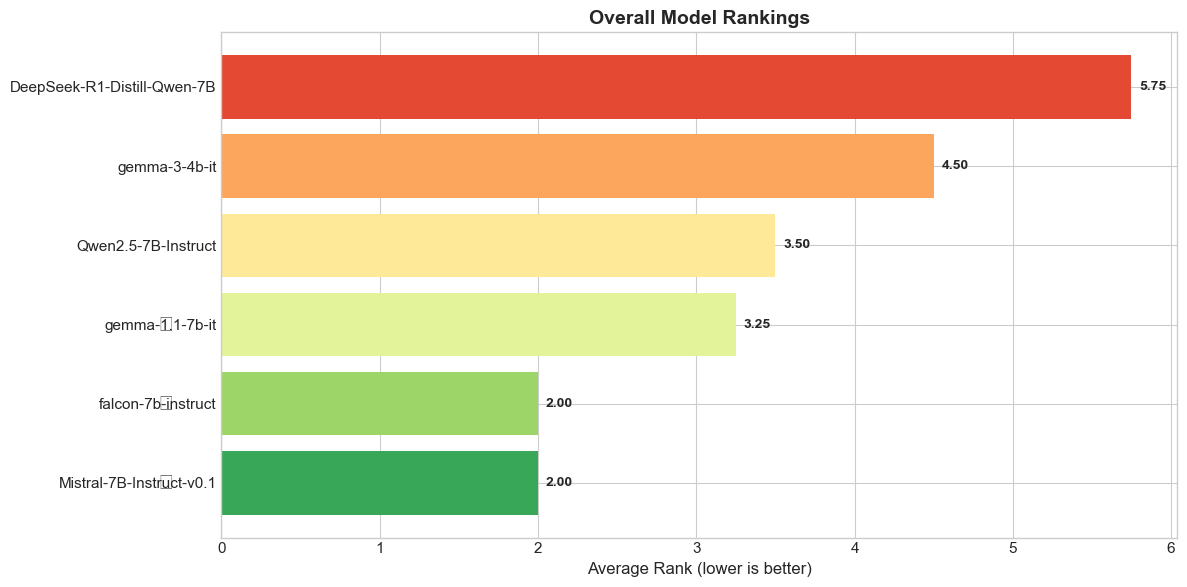

✓ Saved: figures/overall_rankings.png


In [16]:
# Visualize rankings
fig, ax = plt.subplots(figsize=(12, 6))

rank_sorted = rankings_sorted['Average Rank'].sort_values()
colors = sns.color_palette('RdYlGn_r', n_colors=len(rank_sorted))

bars = ax.barh(range(len(rank_sorted)), rank_sorted.values, color=colors)
ax.set_yticks(range(len(rank_sorted)))
ax.set_yticklabels(rank_sorted.index)
ax.set_xlabel('Average Rank (lower is better)')
ax.set_title('Overall Model Rankings', fontweight='bold', fontsize=14)

# Add value labels
for i, (idx, val) in enumerate(rank_sorted.items()):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

# Add position medals
medals = ['🥇', '🥈', '🥉'] + [''] * (len(rank_sorted) - 3)
for i, medal in enumerate(medals):
    if medal:
        ax.text(-0.3, i, medal, va='center', fontsize=16, ha='right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overall_rankings.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Saved: {FIGURES_DIR}/overall_rankings.png")

## 14. Summary Statistics Export

In [17]:
# Export summary statistics
summary_export = model_means.copy()
summary_export['Overall_Rank'] = rankings['Average Rank']
summary_export = summary_export.sort_values('Overall_Rank')

summary_export.to_csv(f'{FIGURES_DIR}/model_comparison_summary.csv')
print(f"✓ Summary exported to: {FIGURES_DIR}/model_comparison_summary.csv")

# Display final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)
summary_export

✓ Summary exported to: figures/model_comparison_summary.csv

FINAL SUMMARY TABLE


,BLEU,Sem,Perplexity,Rouge1,Rouge2,RougeL,TokenCount,Overall_Rank
Model,,,,,,,,
Mistral-7B-Instruct-v0.1,0.0,0.5089,7.0597,0.1385,0.0625,0.1231,110.0,2.00
falcon-7b-instruct,0.0,0.4869,7.1791,0.1975,0.0506,0.1481,64.0,2.00
gemma-1.1-7b-it,0.0,0.4832,11.8543,0.1240,0.0315,0.1240,113.0,3.25
Qwen2.5-7B-Instruct,0.0,0.5178,15.7958,0.1017,0.0343,0.1017,157.0,3.50
gemma-3-4b-it,0.0,0.4941,18.1047,0.1186,0.0172,0.0847,97.0,4.50
DeepSeek-R1-Distill-Qwen-7B,0.0,0.3573,17.4681,0.0882,0.0099,0.0784,185.0,5.75


## 15. List All Saved Figures

In [18]:
# List all saved figures
import glob

saved_files = glob.glob(f'{FIGURES_DIR}/*')
print("\n" + "=" * 60)
print("SAVED FILES")
print("=" * 60)
for f in sorted(saved_files):
    size = os.path.getsize(f) / 1024
    print(f"  📊 {os.path.basename(f)} ({size:.1f} KB)")
print("=" * 60)
print(f"Total: {len(saved_files)} files saved to '{os.path.abspath(FIGURES_DIR)}'")


SAVED FILES
  📊 bleu_comparison.png (168.0 KB)
  📊 boxplots_distribution.png (499.1 KB)
  📊 correlation_heatmap.png (179.9 KB)
  📊 model_comparison_summary.csv (0.5 KB)
  📊 overall_rankings.png (140.1 KB)
  📊 perplexity_comparison.png (152.3 KB)
  📊 radar_comparison.png (832.4 KB)
  📊 rouge_comparison.png (240.0 KB)
  📊 sem_vs_perplexity_scatter.png (194.2 KB)
  📊 semantic_similarity_comparison.png (164.6 KB)
  📊 token_count_comparison.png (150.9 KB)
Total: 11 files saved to 'c:\Users\OmarSalah\source\repos\Benchmarking_LLMs\figures'
